# misc/01 -- Temperature Correlations

This supporting notebook explores how per-sensor average values relate to
temperature across the five monthly **AQUINAS** datasets.

- Load all available SET folders
- Compute linear correlations between `Mean_Value` and `Temperature`
- Compare whole-dataset and per-SET behaviour across sensors

**Attribution:** Original temperature-correlation analysis by the original
notebook author. This version is cleaned and restructured to match the
project notebook style while preserving the same analytical flow.

## Setup

Import the analysis libraries and the `aquinas_toolkit` reader used to load
event metadata from each dataset.

In [14]:
from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from aquinas_toolkit import AquinasReader
from aquinas_toolkit.utils import find_dataset_root, list_dataset_dirs

## Load datasets

Load all monthly SET folders from the repo-level `AQUINAS_DATASET`
directory using the shared toolkit helper.

In [15]:
dataset_root = find_dataset_root()
dataset_dirs = list_dataset_dirs(dataset_root)
readers = [AquinasReader(d) for d in dataset_dirs]

In [16]:
print(f"Dataset root: {dataset_root}")
print(f"Loaded {len(readers)} datasets")
dataset_dirs

Dataset root: C:\Users\murat\Documents\GitHub\EWSHM_Competition\AQUINAS_DATASET
Loaded 5 datasets


[WindowsPath('C:/Users/murat/Documents/GitHub/EWSHM_Competition/AQUINAS_DATASET/AQUINAS_SET1_2022_07'),
 WindowsPath('C:/Users/murat/Documents/GitHub/EWSHM_Competition/AQUINAS_DATASET/AQUINAS_SET2_2023_04'),
 WindowsPath('C:/Users/murat/Documents/GitHub/EWSHM_Competition/AQUINAS_DATASET/AQUINAS_SET3_2023_08'),
 WindowsPath('C:/Users/murat/Documents/GitHub/EWSHM_Competition/AQUINAS_DATASET/AQUINAS_SET4_2024_01'),
 WindowsPath('C:/Users/murat/Documents/GitHub/EWSHM_Competition/AQUINAS_DATASET/AQUINAS_SET5_2024_06')]

## Compute per-sensor correlations

For each sensor, gather event metadata across all sets, plot `Mean_Value`
and `Temperature` over time, and store both overall and per-SET linear
correlations.


Sensor: NEW_S1_DO_INF_STR


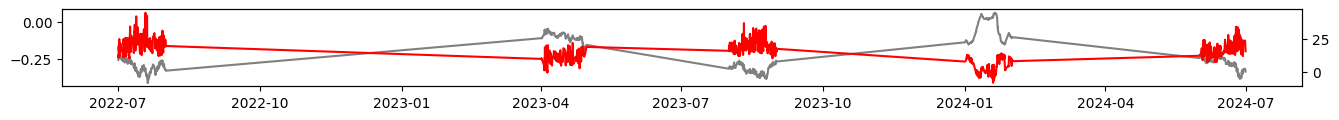

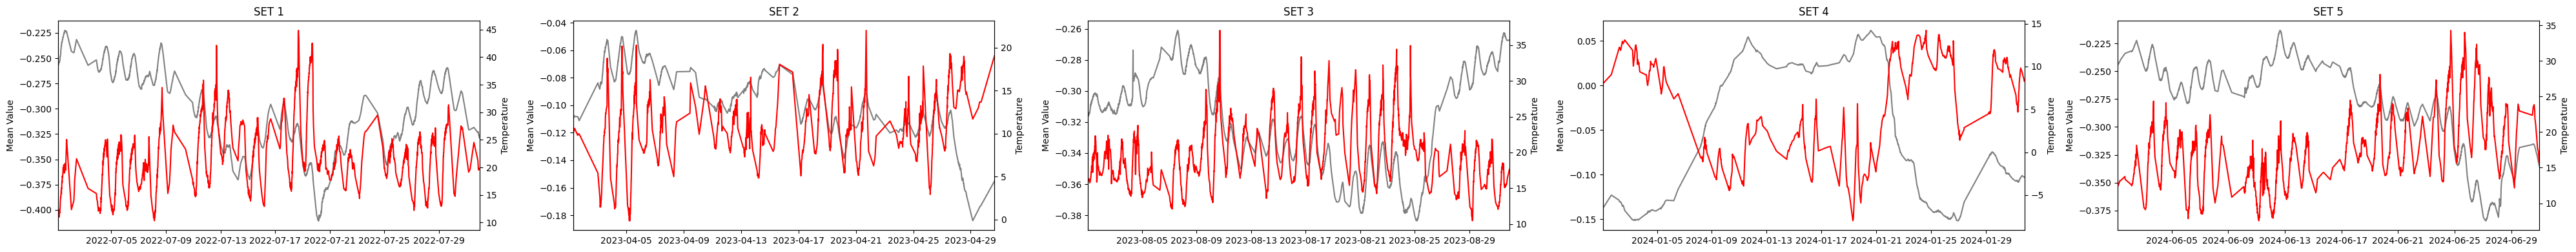


Sensor: NEW_S1_DO_INT_ACC_Y


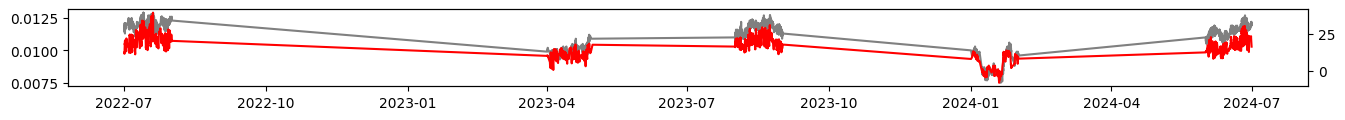

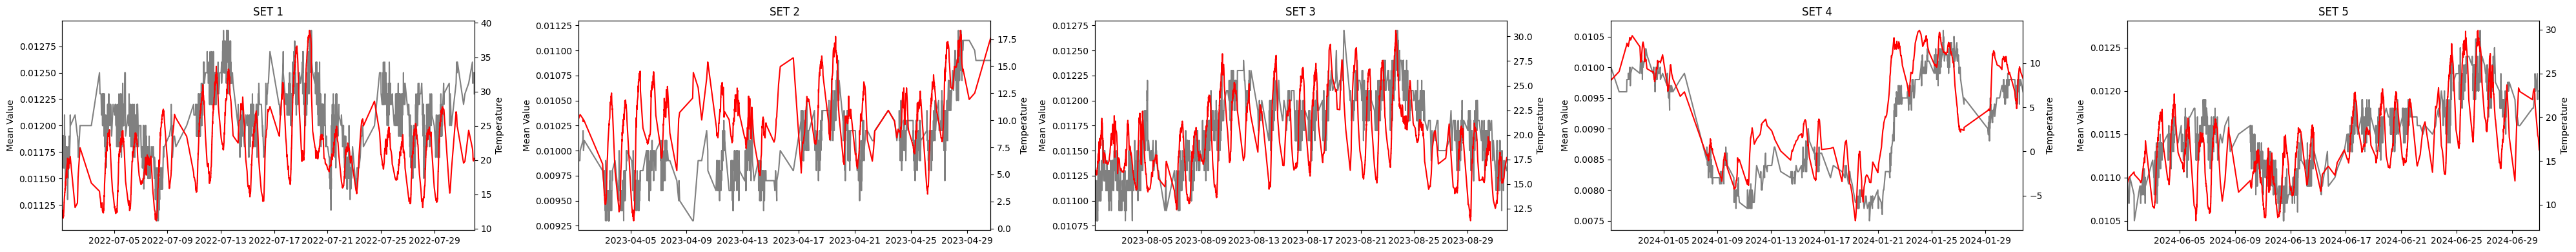


Sensor: NEW_S1_DO_INT_ACC_Z


KeyboardInterrupt: 

In [17]:
sensors = readers[0].list_sensor_names()
full_corrs = {}
set_corrs = {}

for sensor in sensors:
    print(f"\nSensor: {sensor}")

    index_dfs = [reader.load_index_table(sensor) for reader in readers]
    metas = []

    for i, index_df in enumerate(index_dfs):
        for event_num in range(len(index_df)):
            meta, _event_df = readers[i].read_record(sensor_name=sensor, row_index=event_num)
            metas.append(meta)

    meta_df = pd.DataFrame(metas)
    meta_df["Set"] = meta_df["File"].str.extract(r"SET(\d+)")
    meta_df["Start_Time"] = pd.to_datetime(meta_df["Start_Time"])
    meta_df["End_Time"] = pd.to_datetime(meta_df["End_Time"])

    plt.figure(figsize=(16, 1))
    ax1 = plt.gca()
    ax1.plot(meta_df["Start_Time"], meta_df["Mean_Value"], color="grey")

    ax2 = ax1.twinx()
    ax2.plot(meta_df["Start_Time"], meta_df["Temperature"], color="red")

    groups = meta_df.groupby("Set")
    n_sets = len(groups)

    full_corrs[sensor] = meta_df[["Mean_Value", "Temperature"]].corr().iloc[0, 1]
    set_corrs[sensor] = (
        groups[["Mean_Value", "Temperature"]]
        .corr()
        .unstack()["Mean_Value"]["Temperature"]
    )

    fig, axes = plt.subplots(1, n_sets, figsize=(40, 4), sharex=False)
    if n_sets == 1:
        axes = [axes]

    for (set_num, group), ax in zip(groups, axes):
        ax.plot(group["Start_Time"], group["Mean_Value"], color="grey", label="Mean Value")
        ax.set_ylabel("Mean Value")
        ax.set_title(f"SET {set_num}")

        ax2 = ax.twinx()
        ax2.plot(group["Start_Time"], group["Temperature"], color="red", label="Temperature")
        ax2.set_ylabel("Temperature")

        xmin, xmax = group["Start_Time"].min(), group["Start_Time"].max()
        ax.set_xlim(xmin, xmax)

    plt.tight_layout()
    plt.show()

## Summarise overall sensor correlations

Build one correlation value per sensor across the combined event metadata
from all available sets.

C:\Users\murat\AppData\Local\Temp\ipykernel_64168\3385580996.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="sensor", x="temp_corr", data=df_fullcorr, palette=colors)
C:\Users\murat\AppData\Local\Temp\ipykernel_64168\3385580996.py:8: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(y="sensor", x="temp_corr", data=df_fullcorr, palette=colors)


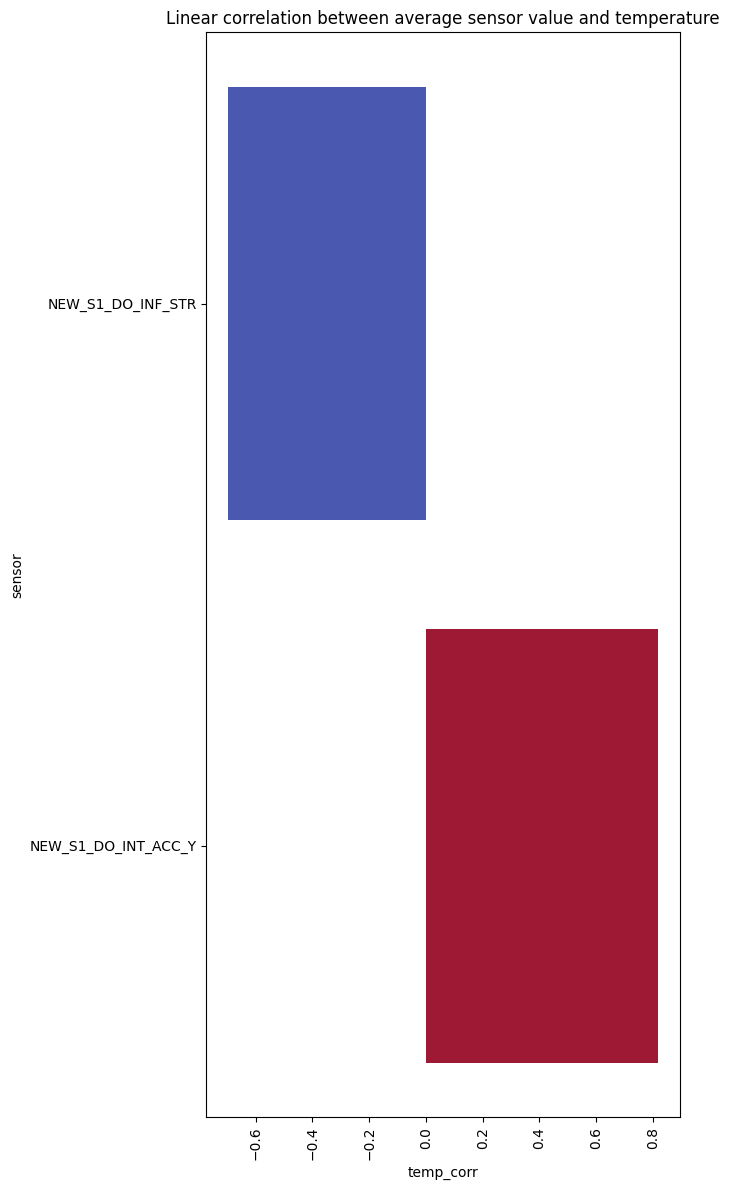

In [18]:
df_fullcorr = pd.DataFrame(list(full_corrs.items()), columns=["sensor", "temp_corr"])

plt.figure(figsize=(7, 12))

norm = plt.Normalize(df_fullcorr["temp_corr"].min(), df_fullcorr["temp_corr"].max())
colors = plt.cm.coolwarm(norm(df_fullcorr["temp_corr"]))

sns.barplot(y="sensor", x="temp_corr", data=df_fullcorr, palette=colors)

plt.xticks(rotation=90)
plt.title("Linear correlation between average sensor value and temperature")
plt.tight_layout()

## Final heatmap by set

Compare the per-SET correlation between `Mean_Value` and `Temperature`
for each sensor.

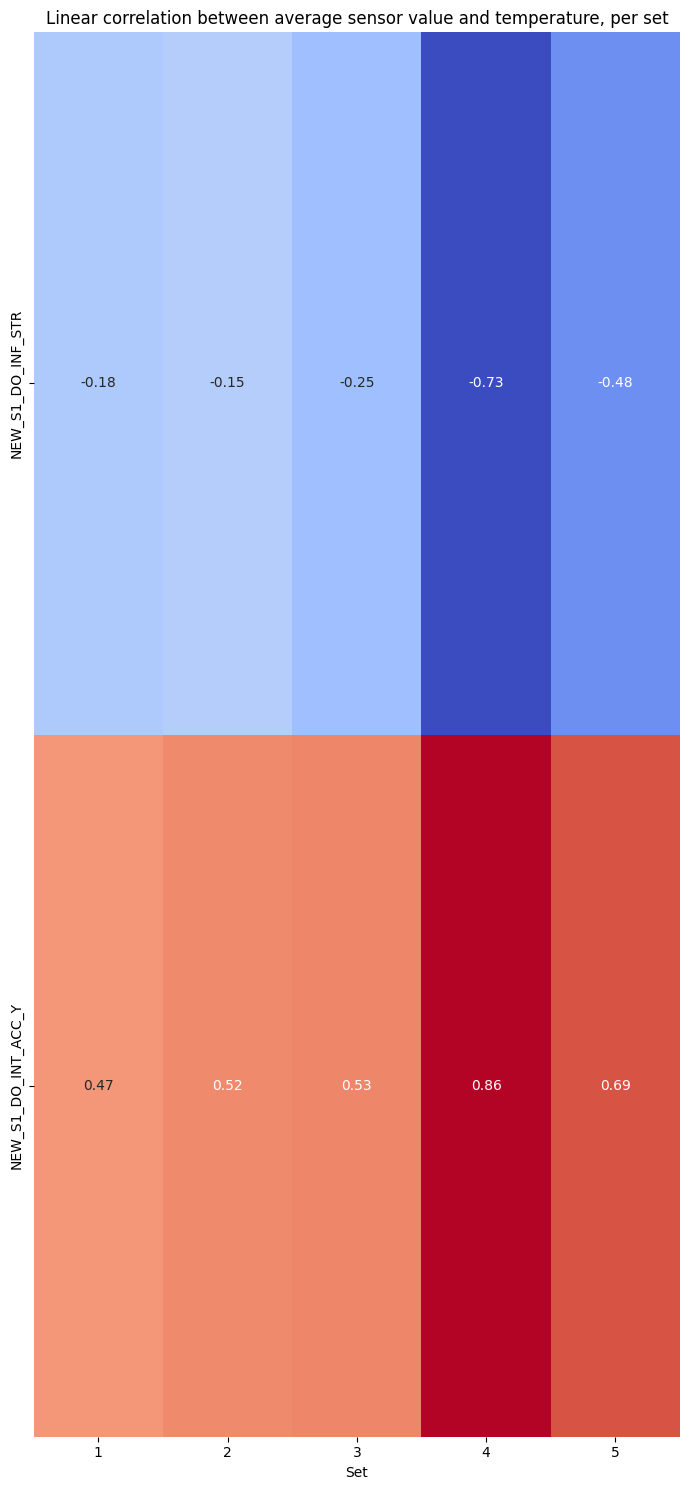

In [19]:
plt.figure(figsize=(7, 15))

sns.heatmap(pd.DataFrame(set_corrs).T, cmap="coolwarm", cbar=False, annot=True)

plt.title("Linear correlation between average sensor value and temperature, per set")
plt.tight_layout()